In [2]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = 5548
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(5548)
n = 200
t = np.sort(rng.uniform(0, 10, n))          # monotonic timestamps
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n)

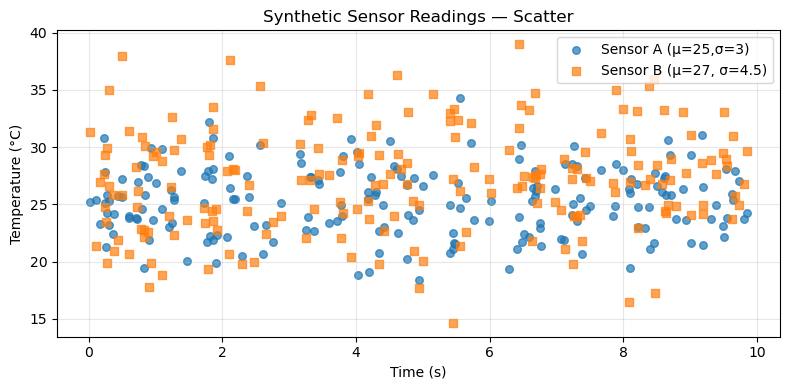

In [3]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(5548)
n = 200
timestamps = np.sort(rng.uniform(0.0, 10.0, size=n)).astype(np.float64)   # (200,) float64
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n).astype(np.float64)     # (200,) float64
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n).astype(np.float64)     # (200,) float64

 # quick sanity checks
assert timestamps.shape == (200,) and timestamps.dtype == np.float64
assert sensor_a.shape == (200,) and sensor_a.dtype == np.float64
assert sensor_b.shape == (200,) and sensor_b.dtype == np.float64
plt.figure(figsize=(8,4))
plt.scatter(timestamps, sensor_a, c='tab:blue', s=30, alpha=0.7, label='Sensor A (μ=25,σ=3)')
plt.scatter(timestamps, sensor_b, c='tab:orange', s=30, alpha=0.7, marker='s',
label='Sensor B (μ=27, σ=4.5)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Synthetic Sensor Readings — Scatter')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

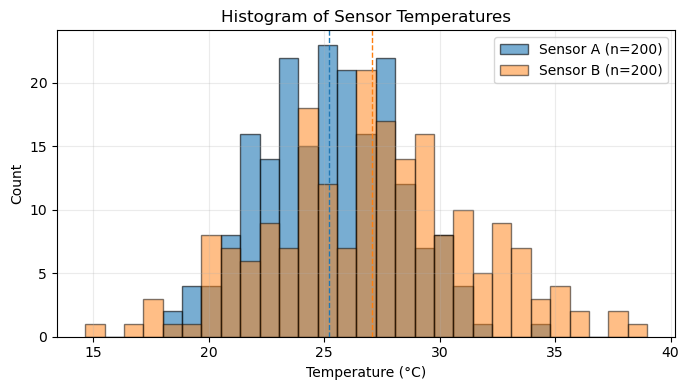

In [ ]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

import numpy as np
import matplotlib.pyplot as plt

# assume sensor_a, sensor_b are present (each (200,) float64)
# create shared bins covering both datasets
all_min = min(sensor_a.min(), sensor_b.min())
all_max = max(sensor_a.max(), sensor_b.max())
bins = np.linspace(all_min, all_max, 30)

rng = np.random.default_rng(5548)
n = 200
timestamps = np.sort(rng.uniform(0.0, 10.0, size=n)).astype(np.float64)   # (200,) float64
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n).astype(np.float64)     # (200,) float64
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n).astype(np.float64)     # (200,) float64


plt.figure(figsize=(7,4))
plt.hist(sensor_a, bins=bins, alpha=0.6, color='tab:blue', label='Sensor A (n=200)',edgecolor='k')
plt.hist(sensor_b, bins=bins, alpha=0.5, color='tab:orange', label='Sensor B (n=200)',edgecolor='k')
plt.axvline(sensor_a.mean(), color='tab:blue', linestyle='--', linewidth=1)
plt.axvline(sensor_b.mean(), color='tab:orange', linestyle='--', linewidth=1)
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram of Sensor Temperatures')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


C:\Users\linke\AppData\Local\Temp\ipykernel_22136\2992298165.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=True, showmeans=True,


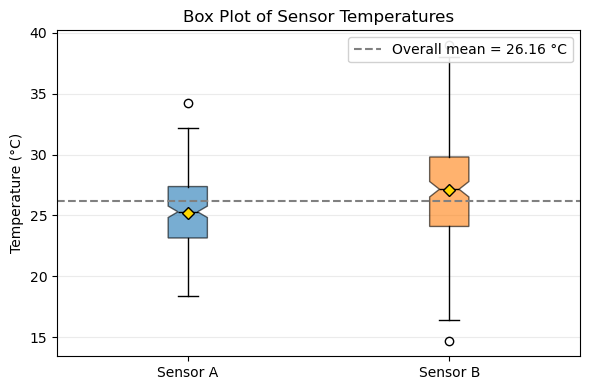

In [7]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(5548)
n = 200
timestamps = np.sort(rng.uniform(0.0, 10.0, size=n)).astype(np.float64)   # (200,) float64
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n).astype(np.float64)     # (200,) float64
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n).astype(np.float64)     # (200,) float64



data = [sensor_a, sensor_b]
labels = ['Sensor A', 'Sensor B']
fig, ax = plt.subplots(figsize=(6,4))
bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=True, showmeans=True,
                 meanprops=dict(marker='D', markeredgecolor='black',markerfacecolor='gold'))

colors = ['tab:blue', 'tab:orange']
for patch, color in zip(bp['boxes'], colors):
     patch.set_facecolor(color); patch.set_alpha(0.6)

for artist in ('whiskers','caps','medians','means'):
     for obj in bp.get(artist, []):
         obj.set_color('black')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Box Plot of Sensor Temperatures')
ax.grid(axis='y', alpha=0.25)
 # compute overall mean of both sensors
overall_mean = np.concatenate([sensor_a, sensor_b]).mean()

 # after creating the boxplot (bp) and setting styles:
ax.axhline(overall_mean, color='gray', linestyle='--', linewidth=1.5,
            label=f'Overall mean = {overall_mean:.2f} °C')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()